In [3]:
import numpy as np
import pycbc
import matplotlib.pyplot as plt
from pycbc.psd import aLIGOAPlusDesignSensitivityT1800042
from pycbc.waveform import get_fd_waveform, get_waveform_filter_length_in_time as chirplen
from pycbc.filter.matchedfilter import overlap, match
from tqdm import tqdm
from pycbc.conversions import mass1_from_tau0_tau3, mass2_from_tau0_tau3, tau0_from_mass1_mass2, tau3_from_mass1_mass2,eta_from_mass1_mass2
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
from pycbc.types.frequencyseries import FrequencySeries
from scipy.interpolate import griddata
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter
from pycbc.conversions import mass1_from_mtotal_eta, mass2_from_mtotal_eta, chi_eff
from pycbc.conversions import tau0_from_mtotal_eta, tau3_from_mtotal_eta,  eta_from_mass1_mass2
from pycbc.waveform.spa_tmplt import findchirp_chirptime, spa_length_in_time
from pycbc.conversions import mchirp_from_mass1_mass2, mass1_from_tau0_tau3, mass2_from_tau0_tau3, tau0_from_mass1_mass2, tau3_from_mass1_mass2

In [4]:
# mass1_from_mtotal_eta(mtotal, eta), mass2_from_mtotal_eta(mtotal, eta), tau0_from_mtotal_eta(mtotal, eta, f_lower),
# tau3_from_mtotal_eta(mtotal, eta, f_lower)

In [5]:
def get_wf(params, Nf):
    try:
        if params["mass1"] <=0 or params["mass2"]<= 0:
            return None
        
        wf, _ = get_fd_waveform(template = None, **params)
        
        if len(wf) != Nf:
            wf.resize(Nf)
        return wf
    
    except Exception as e:
        return None

$$
\tau_0 = \frac{\theta_0}{2 \pi f_{\text{low}}}
$$

$$
\tau_3 = \frac{\theta_3}{2 \pi f_{\text{low}}}
$$

In [6]:
def m1_m2f_theta03(theta0, theta3, flow):
    m1 = mass1_from_tau0_tau3(theta0/(2*np.pi*flow), theta3/(2*np.pi*flow), flow)
    m2 = mass2_from_tau0_tau3(theta0/(2*np.pi*flow), theta3/(2*np.pi*flow), flow)
    return m1, m2

In [7]:
def theta03(m1, m2, flow):
    theta0 = 2*np.pi * flow * tau0_from_mass1_mass2(m1, m2, flow)
    theta3 = 2*np.pi * flow * tau3_from_mass1_mass2(m1, m2, flow)
    return theta0, theta3

In [8]:
def theta3s_m_s(m1, m2, s1z, s2z, flow, eps=1e-12):
    eta = eta_from_mass1_mass2(m1, m2)
    delta = (m1 - m2)/(m1+m2)
    chi_s = 0.5*(s1z+s2z)
    chi_a = 0.5*(s1z-s2z)
    chi_r = chi_s + delta*chi_a - (76/113)*eta*chi_s 
    theta3 = 2*np.pi * flow * tau3_from_mass1_mass2(m1, m2, flow)
    theta3s = (113/(48*np.pi)) * theta3 * chi_r
    # Avoid divide by zero
    chi_r = np.where(np.isclose(chi_r, 0.0), eps, chi_r)
    theta3 = np.where(np.isclose(theta3, 0.0), eps, theta3)
    theta3s = np.where(np.isclose(theta3s, 0.0), eps, theta3s)
    return theta3s

In [9]:
# theta3s_m_s(m1, m2, s1z, s2z, flow, eps=1e-12)

In [10]:
def convert_to_chi1chi2(theta0, theta3, theta3s, flow, condition='', eps=1e-12):

    if np.isclose(theta3, 0.0):
        theta3 = eps

    tau0 = theta0 / (2 * np.pi * flow)
    tau3 = theta3 / (2 * np.pi * flow)

    mass1 = mass1_from_tau0_tau3(tau0, tau3, flow)
    mass2 = mass2_from_tau0_tau3(tau0, tau3, flow)

    eta = eta_from_mass1_mass2(mass1, mass2)
    delta = (mass1 - mass2) / (mass1 + mass2)

    chi_r = (48 * np.pi / 113) * (theta3s / theta3)

    if condition == 'equal_spins':
        spin1z = chi_r / (1 - (76 / 113) * eta)
        spin2z = spin1z

    elif condition == 'zero_secondary':
        spin1z = chi_r / (0.5 + 0.5*delta - (76/226)*eta)
        spin2z = 0

    else:
        raise ValueError("condition must be 'equal_spins' or 'zero_secondary'")

    return np.array([spin1z, spin2z])

In [11]:
# theta0, theta3 = theta03(m1, m2, flow)
# print(theta3)

$$
\Gamma_{ij} = \left( \frac{\partial h}{\partial \theta_i} \,\middle|\, \frac{\partial h}{\partial \theta_j} \right)
$$

with the inner product defined as  

$$
(a|b) = 4 \, \Re \int_{f_{\text{low}}}^{f_{\text{high}}} \frac{\tilde{a}(f) \, \tilde{b}^*(f)}{S_n(f)} \, df \, ,
$$


##### Using finite difference formula to calculate the deravatives 
$$
f'(x) \approx \frac{f(x+h) - f(x-h)}{2h} + \mathcal{O}(h^2)
$$

In [28]:
def metric_3d(params, Nf, psd, fsamp, fhigh, steps, keys=['dtheta0', 'dtheta3', 'dtheta3s', 'tc', 'phi0']):

    if steps is None:
        raise ValueError("`steps` must be provided to metric_3d")

    hp = get_wf(params, Nf)
    f = hp.sample_frequencies

    flow = params['f_lower']
    m1 = params['mass1']
    m2 = params['mass2']
    s1z = params['spin1z']
    s2z = params['spin2z']
    
    if np.isclose(s1z, s2z):
        condition = 'equal_spins'
    else:
        condition = 'zero_secondary'
#         s2z = 0.
        
    delta_f = params['delta_f']

    A = np.abs(hp)
    norm_hp = overlap(hp, hp, psd, flow, fhigh, normalized=False)

    theta0, theta3 = theta03(m1, m2, flow)
    theta3s = theta3s_m_s(m1, m2, s1z, s2z, flow, eps=1e-12)

    derivs_phi = {}
    derivs_amp = {}

    for key in keys:
        dp = steps.get(key)

        if key == 'dtheta0':
            theta0_plus = theta0 + dp
            theta0_minus = theta0 - dp

            m1_plus, m2_plus = m1_m2f_theta03(theta0_plus, theta3, flow)
            m1_minus, m2_minus = m1_m2f_theta03(theta0_minus, theta3, flow)

            # <-- PASS the computed `condition` here
            s1z_plus, s2z_plus = convert_to_chi1chi2(theta0_plus, theta3, theta3s, flow, condition=condition)
            s1z_minus, s2z_minus = convert_to_chi1chi2(theta0_minus, theta3, theta3s, flow, condition=condition)

            valid_plus = (
                not np.iscomplex(m1_plus) and not np.iscomplex(m2_plus)
                and m1_plus > 0 and m2_plus > 0
                and np.isfinite(s1z_plus) and np.isfinite(s2z_plus)
                and abs(s1z_plus) < 1 and abs(s2z_plus) < 1
                and not np.iscomplex(s1z_plus) and not np.iscomplex(s2z_plus)
            )

            valid_minus = (
                not np.iscomplex(m1_minus) and not np.iscomplex(m2_minus)
                and m1_minus > 0 and m2_minus > 0
                and np.isfinite(s1z_minus) and np.isfinite(s2z_minus)
                and abs(s1z_minus) < 1 and abs(s2z_minus) < 1
                and not np.iscomplex(s1z_minus) and not np.iscomplex(s2z_minus)
            )

            if valid_plus and valid_minus:
                use_scheme = 'central'
                params_plus = params.copy()
                params_minus = params.copy()

                params_plus.update({
                    'mass1': float(m1_plus), 'mass2': float(m2_plus),
                    'spin1z': float(s1z_plus), 'spin2z': float(s2z_plus)
                })

                params_minus.update({
                    'mass1': float(m1_minus), 'mass2': float(m2_minus),
                    'spin1z': float(s1z_minus), 'spin2z': float(s2z_minus)
                })

            elif valid_plus:
                use_scheme = 'forward'
                params_plus = params.copy()
                params_plus.update({
                    'mass1': float(m1_plus), 'mass2': float(m2_plus),
                    'spin1z': float(s1z_plus), 'spin2z': float(s2z_plus)
                })

            elif valid_minus:
                use_scheme = 'backward'
                params_minus = params.copy()
                params_minus.update({
                    'mass1': float(m1_minus), 'mass2': float(m2_minus),
                    'spin1z': float(s1z_minus), 'spin2z': float(s2z_minus)
                })

        elif key == 'dtheta3':
            theta3_plus = theta3 + dp
            theta3_minus = theta3 - dp

            m1_plus, m2_plus = m1_m2f_theta03(theta0, theta3_plus, flow)
            m1_minus, m2_minus = m1_m2f_theta03(theta0, theta3_minus, flow)

            # <-- PASS the computed `condition` here
            s1z_plus, s2z_plus = convert_to_chi1chi2(theta0, theta3_plus, theta3s, flow, condition=condition)
            s1z_minus, s2z_minus = convert_to_chi1chi2(theta0, theta3_minus, theta3s, flow, condition=condition)

            valid_plus = (
                not np.iscomplex(m1_plus) and not np.iscomplex(m2_plus)
                and m1_plus > 0 and m2_plus > 0
                and np.isfinite(s1z_plus) and np.isfinite(s2z_plus)
                and abs(s1z_plus) < 1 and abs(s2z_plus) < 1
                and not np.iscomplex(s1z_plus) and not np.iscomplex(s2z_plus)
            )

            valid_minus = (
                not np.iscomplex(m1_minus) and not np.iscomplex(m2_minus)
                and m1_minus > 0 and m2_minus > 0
                and np.isfinite(s1z_minus) and np.isfinite(s2z_minus)
                and abs(s1z_minus) < 1 and abs(s2z_minus) < 1
                and not np.iscomplex(s1z_minus) and not np.iscomplex(s2z_minus)
            )

            if valid_plus and valid_minus:
                use_scheme = 'central'
                params_plus = params.copy()
                params_minus = params.copy()

                params_plus.update({
                    'mass1': float(m1_plus), 'mass2': float(m2_plus),
                    'spin1z': float(s1z_plus), 'spin2z': float(s2z_plus)
                })

                params_minus.update({
                    'mass1': float(m1_minus), 'mass2': float(m2_minus),
                    'spin1z': float(s1z_minus), 'spin2z': float(s2z_minus)
                })

            elif valid_plus:
                use_scheme = 'forward'
                params_plus = params.copy()
                params_plus.update({
                    'mass1': float(m1_plus), 'mass2': float(m2_plus),
                    'spin1z': float(s1z_plus), 'spin2z': float(s2z_plus)
                })

            elif valid_minus:
                use_scheme = 'backward'
                params_minus = params.copy()
                params_minus.update({
                    'mass1': float(m1_minus), 'mass2': float(m2_minus),
                    'spin1z': float(s1z_minus), 'spin2z': float(s2z_minus)
                })

        elif key == 'dtheta3s':
            theta3s_plus = theta3s + dp
            theta3s_minus = theta3s - dp

            # <-- PASS the computed `condition` here
            s1z_plus, s2z_plus = convert_to_chi1chi2(theta0, theta3, theta3s_plus, flow, condition=condition)
            s1z_minus, s2z_minus = convert_to_chi1chi2(theta0, theta3, theta3s_minus, flow, condition=condition)
            valid_plus = (
                np.isfinite(s1z_plus) and np.isfinite(s2z_plus)
                and abs(s1z_plus) < 1 and abs(s2z_plus) < 1
                and not np.iscomplex(s1z_plus) and not np.iscomplex(s2z_plus)
            )

            valid_minus = (
                np.isfinite(s1z_minus) and np.isfinite(s2z_minus)
#                 and abs(s1z_minus) < 1 and abs(s2z_minus) < 1
                and not np.iscomplex(s1z_minus) and not np.iscomplex(s2z_minus)
            )

            if valid_plus and valid_minus:
                use_scheme = 'central'
                params_plus = params.copy()
                params_minus = params.copy()

                params_plus.update({
                    'spin1z': float(s1z_plus), 'spin2z': float(s2z_plus)
                })

                params_minus.update({
                    'spin1z': float(s1z_minus), 'spin2z': float(s2z_minus)
                })

            elif valid_plus:
                use_scheme = 'forward'
                params_plus = params.copy()
                params_plus.update({
                    'spin1z': float(s1z_plus), 'spin2z': float(s2z_plus)
                })

            elif valid_minus:
                use_scheme = 'backward'
                params_minus = params.copy()
                params_minus.update({
                    'spin1z': float(s1z_minus), 'spin2z': float(s2z_minus)
                })

        elif key == 'tc':
            derivs_phi[key] = FrequencySeries(2 * np.pi * f, delta_f)
            derivs_amp[key] = FrequencySeries(np.zeros(Nf), delta_f)
            continue

        elif key == 'phi0':
            derivs_phi[key] = FrequencySeries(np.ones(Nf), delta_f)
            derivs_amp[key] = FrequencySeries(np.zeros(Nf), delta_f)
            continue

        if use_scheme == 'central':
            h_plus = get_wf(params_plus, Nf)
            h_minus = get_wf(params_minus, Nf)

            phi_plus = np.unwrap(np.angle(h_plus))
            phi_minus = np.unwrap(np.angle(h_minus))

            amp_plus = np.abs(h_plus)
            amp_minus = np.abs(h_minus)

            derivs_phi[key] = (phi_plus - phi_minus) / (2 * dp)
            derivs_amp[key] = (amp_plus - amp_minus) / (2 * dp)

        elif use_scheme == 'forward':
            h_plus = get_wf(params_plus, Nf)
            h0 = get_wf(params, Nf)

            phi_plus = np.unwrap(np.angle(h_plus))
            phi0 = np.unwrap(np.angle(h0))

            amp_plus = np.abs(h_plus)
            amp0 = np.abs(h0)

            derivs_phi[key] = (phi_plus - phi0) / dp
            derivs_amp[key] = (amp_plus - amp0) / dp

        elif use_scheme == 'backward':
            h_minus = get_wf(params_minus, Nf)
            h0 = get_wf(params, Nf)

            phi_minus = np.unwrap(np.angle(h_minus))
            phi0 = np.unwrap(np.angle(h0))

            amp_minus = np.abs(h_minus)
            amp0 = np.abs(h0)

            derivs_phi[key] = (phi0 - phi_minus) / dp
            derivs_amp[key] = (amp0 - amp_minus) / dp

    n = list(keys)
    k = len(n)

    F = np.zeros((k, k))

    for i in range(k):
        for j in range(k):
            key_i = n[i]
            key_j = n[j]

            t1 = overlap(A * derivs_phi[key_i],
                         A * derivs_phi[key_j],
                         psd, flow, fhigh, normalized=False)

            t2 = overlap(derivs_amp[key_i],
                         derivs_amp[key_j],
                         psd, flow, fhigh, normalized=False)

            F[i, j] = (t1 + t2) / (2 * norm_hp)

    G1 = F[:3, :3]
    G2 = F[:3, 3:]
    G3 = F[3:, 3:]
    G4 = F[3:, :3]

    G3_inv = np.linalg.inv(G3)
    g = G1 - G2 @ G3_inv @ G4

    return g

In [61]:
m1, m2 = 9., 2.
s1z, s2z = 0.5,0.05

In [62]:
fsamp, flow, fhigh = 2048, 30, 1024
kwargs = {'mass1': m1,
        'mass2': m2,
        'spin1z': s1z,
        'spin2z': s2z,
        'f_lower': flow}

In [63]:
sig_duration = chirplen(approximant = 'IMRPhenomD',**kwargs)
seglen = 2 ** (int(np.log2(sig_duration)) + 1)
print(f"Signal Duration : {sig_duration} s")
print(f"signal length : {seglen}")

Signal Duration : 10.443234572438636 s
signal length : 16


In [64]:
delta_f = 1./ seglen
Nt = fsamp * seglen
Nf = int(Nt/2 + 1)

In [65]:
psd = pycbc.psd.aLIGOZeroDetHighPower(Nf, delta_f, flow) #o2 psd
psd.data[np.where(psd.data == 0)[0]] = 10**(-50)

In [66]:
params = {
    'approximant': 'IMRPhenomD',
    'mass1': m1,
    'mass2': m2,
    'spin1z': s1z,
    'spin2z': s2z,
    'delta_f': delta_f,
    'f_lower': flow,
    'mode_array': None}


step = {'dtheta0': 1e-5,
    'dtheta3': 1e-5,
    'dtheta3s': 1e-5,
    'tc': 1e-3,     
    'phi0': 1e-3}

In [67]:
g_ref = metric_3d(params, Nf, psd, fsamp, fhigh, step, keys=['dtheta0', 'dtheta3', 'dtheta3s', 'tc', 'phi0'])

In [94]:
g_ref

array([[ 0.00850876, -0.01137009,  0.01707717],
       [-0.01137009,  0.01669512, -0.02471016],
       [ 0.01707717, -0.02471016,  0.03665618]])

In [95]:
g_03 = np.array([[g_ref[0, 0], g_ref[0, 1]],
                    [g_ref[1, 0], g_ref[1, 1]]])
g_03

array([[ 0.00850876, -0.01137009],
       [-0.01137009,  0.01669512]])

In [96]:
g_03s = np.array([[g_ref[0, 0], g_ref[0, 2]],
                    [g_ref[2, 0], g_ref[2, 2]]])
g_03s

array([[0.00850876, 0.01707717],
       [0.01707717, 0.03665618]])

In [97]:
g_33s = np.array([[g_ref[1, 1], g_ref[1, 2]],
                    [g_ref[2, 1], g_ref[2, 2]]])
g_33s

array([[ 0.01669512, -0.02471016],
       [-0.02471016,  0.03665618]])

In [98]:
theta0, theta3 = theta03(m1, m2, flow)
theta3s = theta3s_m_s(m1, m2, s1z, s2z, flow, eps=1e-12)
cparams = params.copy()

In [99]:
def metric_pts_1(metric, N):
    eigvals, eigvecs = np.linalg.eig(metric)
    R = 1
    np.random.seed(0)
    x1 = np.random.rand(N)
    x2 = np.random.rand(N)
    r = R * np.sqrt(x1)
    theta = x2 * 2 * np.pi
    u1 = r * np.cos(theta)
    u2 = r * np.sin(theta)
    
    y1 = u1/ np.sqrt(eigvals[0])
    y2 = u2/ np.sqrt(eigvals[1])

    s_pts = np.vstack([y1, y2]) # scaling
    
    o = eigvecs @ s_pts # rotation
    e_pts = o.T
    
    return e_pts 

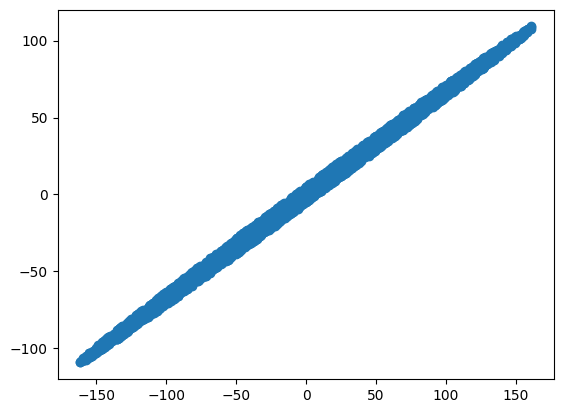

In [100]:
k1 = metric_pts_1(g_33s ,3000)
plt.scatter(k1[:, 0], k1[:, 1])

In [101]:
exact_match1 = []

hp = get_wf(cparams, Nf)
if hp is not None:
    for i in tqdm(range(len(k1))):
        dx, dy = k1[i]
        params_plus = params.copy()
        theta3_plus = theta3 + dx
        theta3s_plus = theta3s + dy
        if np.isclose(s1z, s2z):
            condition = 'equal_spins'
        else:
            condition = 'zero_secondary'
        
        m1_plus, m2_plus = m1_m2f_theta03(theta0, theta3_plus, flow)
        eta_plus = eta_from_mass1_mass2(m1_plus,  m2_plus)
        s1z_plus, s2z_plus = convert_to_chi1chi2(theta0, theta3_plus, theta3s_plus, flow,  condition =  condition)
        
        if not(0 < eta_plus <= 0.25):
            exact_match1.append(0.)
            continue
        if abs(s1z_plus) > 1 or abs(s2z_plus) > 1:
            exact_match1.append(0.)
            continue
        params_plus.update({
            "mass1": m1_plus,
            "mass2": m2_plus,
            "spin1z": s1z_plus,
            "spin2z": s2z_plus
        })
        hp_plus = get_wf(params_plus, Nf)  # safe waveform
        
        if hp_plus is not None:  # only compute match if valid
            try:
                match_val = match(hp, hp_plus, psd, flow, fhigh)[0]
                exact_match1.append(match_val)
            except Exception:
                exact_match1.append(0.)
        else:
            exact_match1.append(0.)
        del hp_plus  # free memory each iteration
        
else:
    print("Reference waveform could not be generated.")

  0%|                                                        | 2/3000 [00:00<04:35, 10.90it/s]/home/kumar.tarun/mywork/enve/pycbc/lib/python3.8/site-packages/pycbc/conversions.py:177: RuntimeWarning: invalid value encountered in scalar power
  return 0.5 * mtotal * (1.0 + (1.0 - 4.0 * eta)**0.5)
/home/kumar.tarun/mywork/enve/pycbc/lib/python3.8/site-packages/pycbc/conversions.py:184: RuntimeWarning: invalid value encountered in scalar power
  return 0.5 * mtotal * (1.0 - (1.0 - 4.0 * eta)**0.5)
100%|█████████████████████████████████████████████████████| 3000/3000 [02:43<00:00, 18.33it/s]


In [102]:
match_metric1 = []
for i in range(len(k1)):
    t = k1[i]
    m_metric =  1- (np.dot(t, np.dot(g_33s, t)))
    match_metric1.append(m_metric)

In [103]:
#thet0, theta3s

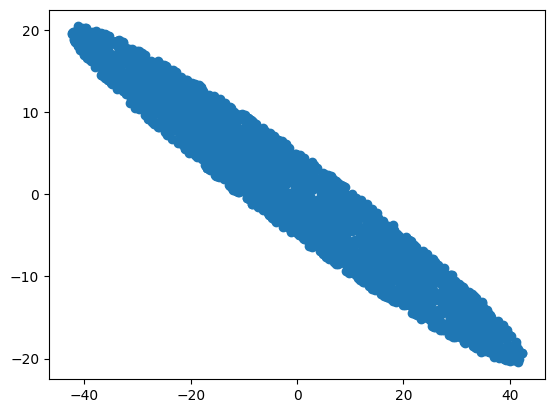

In [104]:
k2 = metric_pts_1(g_03s ,3000)
plt.scatter(k2[:, 0], k2[:, 1])

In [105]:
exact_match2 = []

hp = get_wf(cparams, Nf)
if hp is not None:
    for i in tqdm(range(len(k2))):
        dx, dy = k2[i]
        params_plus = params.copy()
        theta0_plus = theta0 + dx
        theta3s_plus = theta3s + dy
        if np.isclose(s1z, s2z):
            condition = 'equal_spins'
        else:
            condition = 'zero_secondary'
        
        m1_plus, m2_plus = m1_m2f_theta03(theta0_plus, theta3, flow)
        eta_plus = eta_from_mass1_mass2(m1_plus,  m2_plus)
        s1z_plus, s2z_plus = convert_to_chi1chi2(theta0_plus, theta3, theta3s_plus, flow,  condition =  condition)
        
        if not(0 < eta_plus <= 0.25):
            exact_match2.append(0.)
            continue
        if abs(s1z_plus) > 1 or abs(s2z_plus) > 1:
            exact_match2.append(0.)
            continue
        params_plus.update({
            "mass1": m1_plus,
            "mass2": m2_plus,
            "spin1z": s1z_plus,
            "spin2z": s2z_plus
        })
        hp_plus = get_wf(params_plus, Nf)  # safe waveform

        if hp_plus is not None:  # only compute match if valid
            try:
                match_val = match(hp, hp_plus, psd, flow, fhigh)[0]
                exact_match2.append(match_val)
            except Exception:
                exact_match2.append(0.)
        else:
            exact_match2.append(0.)
        del hp_plus  # free memory each iteration
        
else:
    print("Reference waveform could not be generated.")

100%|█████████████████████████████████████████████████████| 3000/3000 [02:50<00:00, 17.58it/s]


In [106]:
match_metric2 = []
for i in range(len(k2)):
    t = k2[i]
    m_metric =  1- (np.dot(t, np.dot(g_03s, t)))
    match_metric2.append(m_metric)

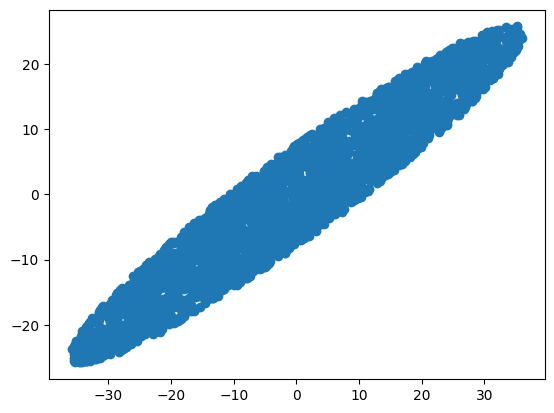

In [107]:
k3 = metric_pts_1(g_03,3000)
plt.scatter(k3[:, 0], k3[:, 1])

In [108]:
exact_match3 = []

hp = get_wf(cparams, Nf)
if hp is not None:
    for i in tqdm(range(len(k3))):
        dx, dy = k3[i]
        params_plus = params.copy()
        theta0_plus = theta0 + dx
        theta3_plus = theta3 + dy
        if np.isclose(s1z, s2z):
            condition = 'equal_spins'
        else:
            condition = 'zero_secondary'        
        
        m1_plus, m2_plus = m1_m2f_theta03(theta0_plus, theta3_plus, flow)
        s1z_plus, s2z_plus = convert_to_chi1chi2(theta0_plus,theta3_plus, theta3s, flow, condition = condition)
        eta_plus = eta_from_mass1_mass2(m1_plus,  m2_plus)
        if not(0 < eta_plus <= 0.25):
            exact_match3.append(0.)
            continue
        if abs(s1z_plus) > 1 or abs(s2z_plus) > 1:
            exact_match3.append(0.)
            continue
        params_plus.update({
            "mass1": m1_plus,
            "mass2": m2_plus,
            "spin1z":s1z_plus,
            "spin2z":s2z_plus
        })
        hp_plus = get_wf(params_plus, Nf)  # safe waveform

        if hp_plus is not None:  # only compute match if valid
            try:
                match_val = match(hp, hp_plus, psd, flow, fhigh)[0]
                exact_match3.append(match_val)
            except Exception:
                exact_match3.append(0.)
        else:
            exact_match3.append(0.)
        del hp_plus  # free memory each iteration
        
else:
    print("Reference waveform could not be generated.")

100%|█████████████████████████████████████████████████████| 3000/3000 [02:38<00:00, 18.88it/s]


In [109]:
len(exact_match3)

3000

In [112]:
match_metric3 = []
for i in range(len(k3)):
    t = k3[i]
    m_metric =  1- (np.dot(t, np.dot(g_03, t)))
    match_metric3.append(m_metric)

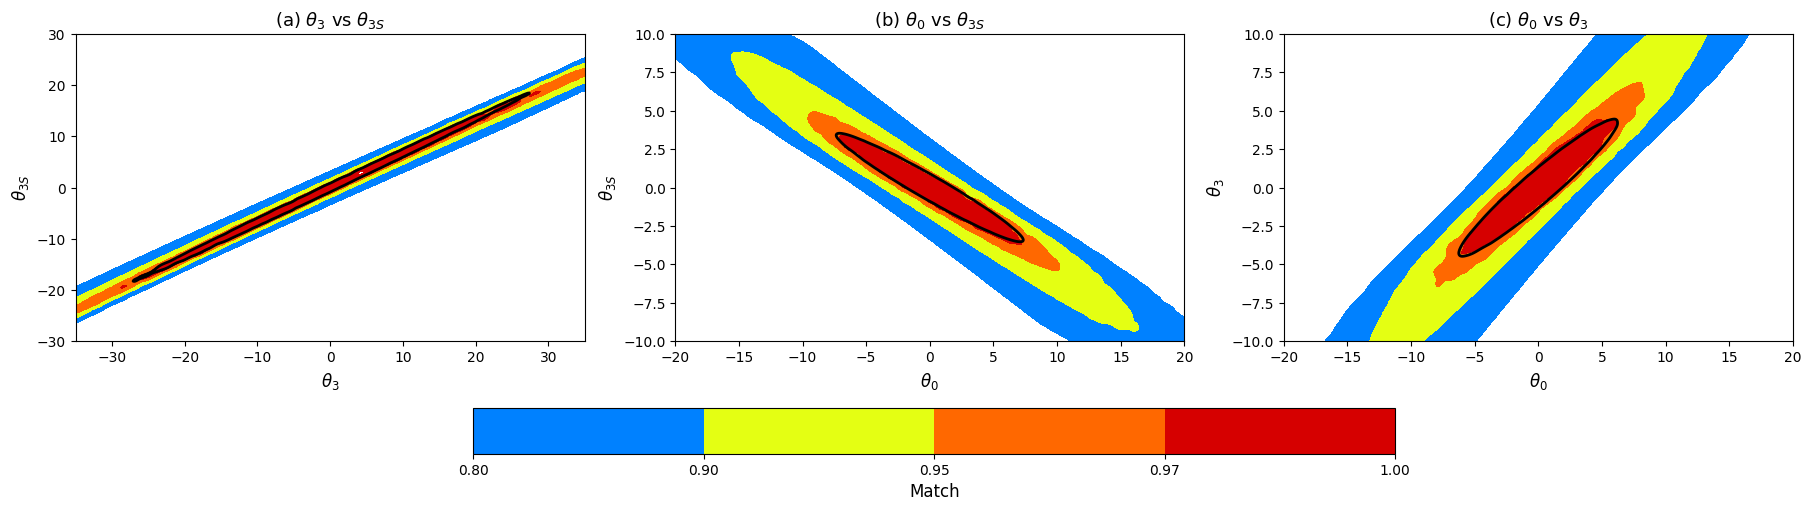

In [113]:
# --- Common plotting setup ---
n = 400
levels = [0.8, 0.9, 0.95, 0.97, 1.0]
sigma = 1.2  

def interpolate_and_smooth(k, exact_match, match_metric, xlim=(-20, 20), ylim=(-10, 10), mask_threshold=1e-5):
    exact_match = np.asarray(exact_match)
    match_metric = np.asarray(match_metric)
    
    x_grid = np.linspace(xlim[0], xlim[1], n)
    y_grid = np.linspace(ylim[0], ylim[1], n)
    X, Y = np.meshgrid(x_grid, y_grid)

    # Mask invalid points (avoid 0 or near-0 matches)
    valid_mask = (exact_match > mask_threshold) & (match_metric > mask_threshold)
    k_valid = k[valid_mask]
    exact_valid = exact_match[valid_mask]
    metric_valid = match_metric[valid_mask]

    # Interpolate only valid points
    Z_exact = griddata((k_valid[:, 0], k_valid[:, 1]), exact_valid, (X, Y), method='cubic')
    Z_metric = griddata((k_valid[:, 0], k_valid[:, 1]), metric_valid, (X, Y), method='cubic')

    # Apply Gaussian
    Z_exact = gaussian_filter(np.nan_to_num(Z_exact, nan=0.0), sigma=sigma)
    Z_metric = gaussian_filter(np.nan_to_num(Z_metric, nan=0.0), sigma=sigma)

    # Mask regions where interpolated values remain near zero ---
    Z_exact = np.ma.masked_where(Z_exact <= mask_threshold, Z_exact)
    Z_metric = np.ma.masked_where(Z_metric <= mask_threshold, Z_metric)

    return X, Y, Z_exact, Z_metric


X1, Y1, Z_exact1, Z_metric1 = interpolate_and_smooth(k1, exact_match1, match_metric1, xlim=(-35, 35), ylim=(-30, 30))
X2, Y2, Z_exact2, Z_metric2 = interpolate_and_smooth(k2, exact_match2, match_metric2, xlim=(-20, 20), ylim=(-10, 10))
X3, Y3, Z_exact3, Z_metric3 = interpolate_and_smooth(k3, exact_match3, match_metric3, xlim=(-20, 20), ylim=(-10, 10))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# --- Plot 1 ---
c1 = axes[0].contourf(X1, Y1, Z_exact1, levels=levels, cmap='jet')
axes[0].contour(X1, Y1, Z_metric1, levels=[0.97], colors='black', linewidths=2)
axes[0].set_xlabel(r'$\theta_3$', fontsize=12)
axes[0].set_ylabel(r'$\theta_{3S}$', fontsize=12)
axes[0].set_title(r'(a) $\theta_3$ vs $\theta_{3S}$', fontsize=13)
axes[0].tick_params(labelsize=10)

# --- Plot 2 ---
c2 = axes[1].contourf(X2, Y2, Z_exact2, levels=levels, cmap='jet')
axes[1].contour(X2, Y2, Z_metric2, levels=[0.97], colors='black', linewidths=2)
axes[1].set_xlabel(r'$\theta_0$', fontsize=12)
axes[1].set_ylabel(r'$\theta_{3S}$', fontsize=12)
axes[1].set_title(r'(b) $\theta_0$ vs $\theta_{3S}$', fontsize=13)
axes[1].tick_params(labelsize=10)

# --- Plot 3 ---
c3 = axes[2].contourf(X3, Y3, Z_exact3, levels=levels, cmap='jet')
axes[2].contour(X3, Y3, Z_metric3, levels=[0.97], colors='black', linewidths=2)
axes[2].set_xlabel(r'$\theta_0$', fontsize=12)
axes[2].set_ylabel(r'$\theta_3$', fontsize=12)
axes[2].set_title(r'(c) $\theta_0$ vs $\theta_3$', fontsize=13)
axes[2].tick_params(labelsize=10)

# --- Shared colorbar on the right ---
cbar = fig.colorbar(c3, ax=axes, orientation='horizontal',  ticks=levels)
cbar.ax.tick_params(labelsize=10)
cbar.set_label('Match', fontsize=12)
# plt.savefig("3_D_METRIC_PLOT.png", dpi = 300)

plt.show()

### Ball Tree implementation

In [114]:
from sklearn.neighbors import BallTree

In [115]:
rng = np.random.default_rng(seed=42)    # choose any seed you want

m1_prop  = rng.uniform(3., 15., 10000000)
m2_prop  = rng.uniform(1., 3., 10000000)
s1z_prop = rng.uniform(-0.6, 0.6, 10000000)
s2z_prop = rng.uniform(-0.05, 0.05, 10000000)

In [116]:
m1_ref, m2_ref = m1, m2
s1z_ref, s2z_ref = s1z, s2z
th0_ref, th3_ref = theta03(m1_ref, m2_ref, flow)
th3s_ref = theta3s_m_s(m1_ref, m2_ref, s1z_ref, s2z_ref, flow, eps=1e-12)

In [117]:
th0, th3  = theta03(m1_prop, m2_prop, flow)
th3s      = theta3s_m_s(m1_prop, m2_prop, s1z_prop, s2z_prop, flow, eps=1e-12)

In [118]:
th03_prop = np.column_stack([th0, th3]) 
th03s_prop = np.column_stack([th0, th3s]) 
th33s_prop = np.column_stack([th3, th3s]) 

In [119]:
from sklearn.neighbors import BallTree

In [120]:
tree03 = BallTree(th03_prop, metric='mahalanobis', VI=g_03)
tree03s = BallTree(th03s_prop, metric='mahalanobis', VI=g_03s)
tree33s = BallTree(th33s_prop, metric='mahalanobis', VI=g_33s)

In [121]:
r_ref03 = np.array([th0_ref, th3_ref])
r_ref03s = np.array([th0_ref, th3s_ref])
r_ref33s = np.array([th3_ref, th3s_ref])

In [122]:
# search radius for overlap >= 0.97
radius = np.sqrt(1 - 0.97)
# query
idxs03 = tree03.query_radius(r_ref03.reshape(1, -1), r=radius)[0]
idxs03s = tree03s.query_radius(r_ref03s.reshape(1, -1), r=radius)[0]
idxs33s = tree33s.query_radius(r_ref33s.reshape(1, -1), r=radius)[0]

In [123]:
mask03 = np.ones(len(th03_prop), dtype=bool)
mask03[idxs03] = False
filtered_prop03 = th03_prop[mask03]
removed_prop03 = th03_prop[idxs03]
removed_prop03 = np.array(removed_prop03)
print(f"Removed {len(idxs03)} proposals, {filtered_prop03.shape[0]} remain.")

Removed 994 proposals, 9999006 remain.


In [124]:
mask03s = np.ones(len(th03s_prop), dtype=bool)
mask03s[idxs03s] = False
filtered_prop03s = th03s_prop[mask03s]
removed_prop03s = th03s_prop[idxs03s]
removed_prop03s = np.array(removed_prop03s)
print(f"Removed {len(idxs03s)} proposals, {filtered_prop03s.shape[0]} remain.")

Removed 476 proposals, 9999524 remain.


In [125]:
mask33s = np.ones(len(th33s_prop), dtype=bool)
mask33s[idxs33s] = False
filtered_prop33s = th33s_prop[mask33s]
removed_prop33s = th33s_prop[idxs33s]
removed_prop33s = np.array(removed_prop33s)
print(f"Removed {len(idxs33s)} proposals, {filtered_prop33s.shape[0]} remain.")

Removed 45300 proposals, 9954700 remain.


In [128]:
# Shift grids by reference values
X_shift1 = X1 + th3_ref
Y_shift1 = Y1 + th3s_ref

In [129]:
# Shift grids by reference values
X_shift2 = X2 + th0_ref
Y_shift2 = Y2 + th3s_ref

In [130]:
# Shift grids by reference values
X_shift3 = X3 + th0_ref
Y_shift3 = Y3 + th3_ref

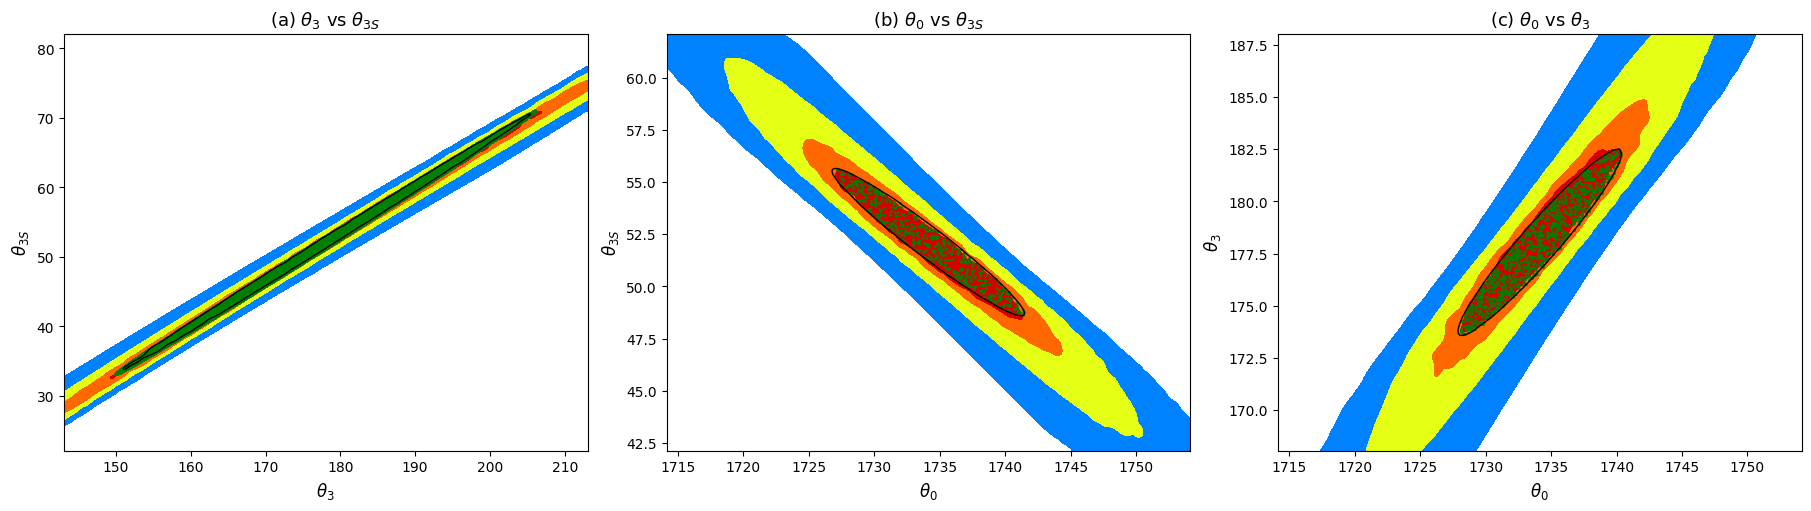

In [131]:
# --- Create 3 horizontal subplots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# --- Plot 1 ---
c1 = axes[0].contourf(X_shift1, Y_shift1, Z_exact1, levels=levels, cmap='jet')
axes[0].scatter(removed_prop33s[:, 0], removed_prop33s[:, 1], color='green', s=1, label='Accepted Points')
axes[0].contour(X_shift1, Y_shift1, Z_metric1, levels=[0.97], colors='black', linewidths=1)
axes[0].set_xlabel(r'$\theta_3$', fontsize=12)
axes[0].set_ylabel(r'$\theta_{3S}$', fontsize=12)
axes[0].set_title(r'(a) $\theta_3$ vs $\theta_{3S}$', fontsize=13)
axes[0].tick_params(labelsize=10)

# --- Plot 2 ---
c2 = axes[1].contourf(X_shift2, Y_shift2, Z_exact2, levels=levels, cmap='jet')
axes[1].scatter(removed_prop03s[:, 0], removed_prop03s[:, 1], color='green', s=1, label='Accepted Points')
axes[1].contour(X_shift2, Y_shift2, Z_metric2, levels=[0.97], colors='black', linewidths=1)
axes[1].set_xlabel(r'$\theta_0$', fontsize=12)
axes[1].set_ylabel(r'$\theta_{3S}$', fontsize=12)
axes[1].set_title(r'(b) $\theta_0$ vs $\theta_{3S}$', fontsize=13)
axes[1].tick_params(labelsize=10)

# --- Plot 3 ---
c3 = axes[2].contourf(X_shift3, Y_shift3, Z_exact3, levels=levels, cmap='jet')
axes[2].scatter(removed_prop03[:, 0], removed_prop03[:, 1], color='green', s=1, label='Accepted Points')
axes[2].contour(X_shift3, Y_shift3, Z_metric3, levels=[0.97], colors='black', linewidths=1)
axes[2].set_xlabel(r'$\theta_0$', fontsize=12)
axes[2].set_ylabel(r'$\theta_3$', fontsize=12)
axes[2].set_title(r'(c) $\theta_0$ vs $\theta_3$', fontsize=13)
axes[2].tick_params(labelsize=10)

# # --- Shared colorbar on the right ---
# cbar = fig.colorbar(c3, ax=axes, orientation='horizontal',  ticks=levels)
# cbar.ax.tick_params(labelsize=10)
# cbar.set_label('Match', fontsize=12)
plt.savefig("ball_tree_3D.png", dpi = 300)

plt.show()